In [2]:
import os
import glob
import json
import yaml
import numpy as np
import torch
import argparse
import igl
import pickle
import trimesh

import sys
from pathlib import Path
__abs_path__ = str(Path.cwd().parents[0].absolute())
__utils_path__ = f'{__abs_path__}/utils'

for __util_path__ in [__abs_path__, __utils_path__]:
    if not __util_path__ in sys.path:
        sys.path+=[__util_path__]

from eval_CBD import Options, Trainer
from utils.arg_util import YamlArgParser
from utils.remesh_utils import ICT_face_model

try:
    from matplotrender import *
except:
    !pip install git+https://github.com/chacorp/matplotrender.git
    from matplotrender import *

from utils.matplotlib_rnd import (
    render_mesh_diff,
    plot_image_array
)

  Cloning https://github.com/chacorp/matplotrender.git to /tmp/pip-req-build-wqyx0ghk
  Running command git clone --filter=blob:none --quiet https://github.com/chacorp/matplotrender.git /tmp/pip-req-build-wqyx0ghk
  Resolved https://github.com/chacorp/matplotrender.git to commit 2ad6593a4e5846a8d7d5f80d47cd64160d4df35a
  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'matplotrender' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'matplotrender'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for matplotrender: filename=matplotrender-0.1.1-py3-none-any.whl size=10262 sha256=3c152197dd7dbad1e8ace20fcde9a22f4d1bd2401d27e31756b34227123d637f
  St

In [26]:
config = f'{__abs_path__}/config/train_CBD.yml'
opts_yaml = yaml.load(open(config), Loader=yaml.FullLoader)
opts = argparse.Namespace(**opts_yaml)

opts.dec_type = 'disp'

opts.ckpt = '../ckpts_CBD/2025-10-20-00-15-40-CBD' ## ------> NeuralCage

opts.in_type=1
opts.out_type=1

opts.num_cage_v=512
# opts.num_cage_v=128

# opts.version=5
opts.version=1
# opts.last_activation='relu'
opts.last_activation='none'

opts.optim_cage=False
opts.no_pou=False

opts.use_data2=True
# opts.use_data2=False
opts.use_data3=False
opts.continue_ckpt=True
opts.start_epoch=100

trainer = Trainer(opts)
trainer.model.eval()
print('done')

Loading... ../ckpts_CBD/2025-10-20-00-15-40-CBD/model_100.pth
done


# Retarget single frame

(3515, 3)
(11248, 3)


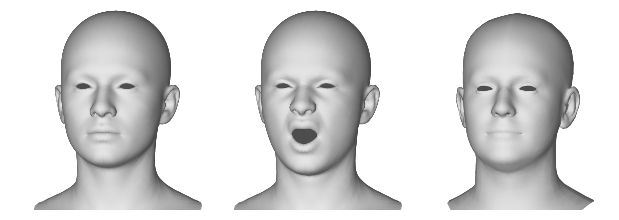

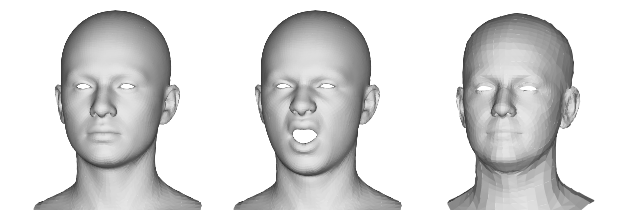

In [9]:
## full head
ict_face_model = ICT_face_model()
ict_tri = ict_face_model.get_mesh()

## flame
flame_tri = trimesh.load(f'{__abs_path__}/test-mesh/flame_final_transformed.obj', process=False, maintain_order=True)
flame_tri.vertices = flame_tri.vertices + np.array([0,0.1,0])
# flame_tri.vertices = flame_tri.vertices + np.array([0,0.2,0])
# flame_tri = trimesh.load(f'{__abs_path__}/test-mesh/biwi_M5.obj', process=False, maintain_order=True)
# flame_tri = trimesh.load(f'{__abs_path__}/test-mesh/biwi_M5_deci.obj', process=False, maintain_order=True)
print(flame_tri.vertices.shape)

## ICT random expression
# bs_coeff = np.eye(53)[26]
bs_coeff = np.eye(53)[51] + np.eye(53)[52] + np.eye(53)[26] * 0.5
vertices = (ict_tri.vertices + ict_face_model.get_exp_disp(bs_coeff)).squeeze()
src_mesh = ict_tri
tgt_mesh = flame_tri


print(ict_tri.vertices.shape)

M_SCALE = 0.68
rot_list=[[0,-10,0]]
SIZE=2
v_list=[ src_mesh.vertices * M_SCALE, vertices * M_SCALE, tgt_mesh.vertices * M_SCALE ]
f_list=[ src_mesh.faces, ict_tri.faces, tgt_mesh.faces ]

plot_mesh_gouraud(
    v_list, f_list, mesh_scale=1, orth_view=True,
    rot_list=rot_list*len(v_list), size=SIZE, mode='shade', 
    bg_black=False, logdir=f"_tmp/train", name=f"test", save=False
)
plot_image_array(
    v_list, f_list,
    rot_list=rot_list*len(v_list), size=SIZE, mode='shade', 
    bg_black=False, logdir=f"_tmp/train", name=f"test", save=False
)

In [83]:
device=trainer.device
print(device)

sd_v = vertices
# print(sd_v.shape)
s_v_B_th = torch.from_numpy(src_mesh.vertices)[None].float().to(device)
s_n_B_th = torch.from_numpy(igl.per_vertex_normals(src_mesh.vertices, src_mesh.faces))[None].float().to(device)
sd_v_B_th = torch.from_numpy(sd_v)[None].float().to(device)
sd_n_B_th = torch.from_numpy(igl.per_vertex_normals(sd_v, src_mesh.faces))[None].float().to(device)

t_v_B_th = torch.from_numpy(tgt_mesh.vertices)[None].float().to(device)
t_n_B_th = torch.from_numpy(igl.per_vertex_normals(tgt_mesh.vertices, tgt_mesh.faces))[None].float().to(device)

pred_outputs, pred_source, exp_z_d, key_d, exp_z_s, key_s, key_weight = trainer.model.retarget(
    s_v_B_th, s_n_B_th, sd_v_B_th, sd_n_B_th, t_v_B_th, t_n_B_th, mesh_data=0, out_kw=True
)


cuda:0


In [88]:
print(key_weight.shape)
qwe = torch.count_nonzero(key_weight[0],dim=0)
print(qwe.min(), qwe.max(), qwe.shape)

print(torch.count_nonzero(qwe))
# key_weight[0][20]
# pred_outputs

torch.Size([1, 3515, 512])
tensor(0, device='cuda:0') tensor(3515, device='cuda:0') torch.Size([512])
tensor(346, device='cuda:0')


 source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


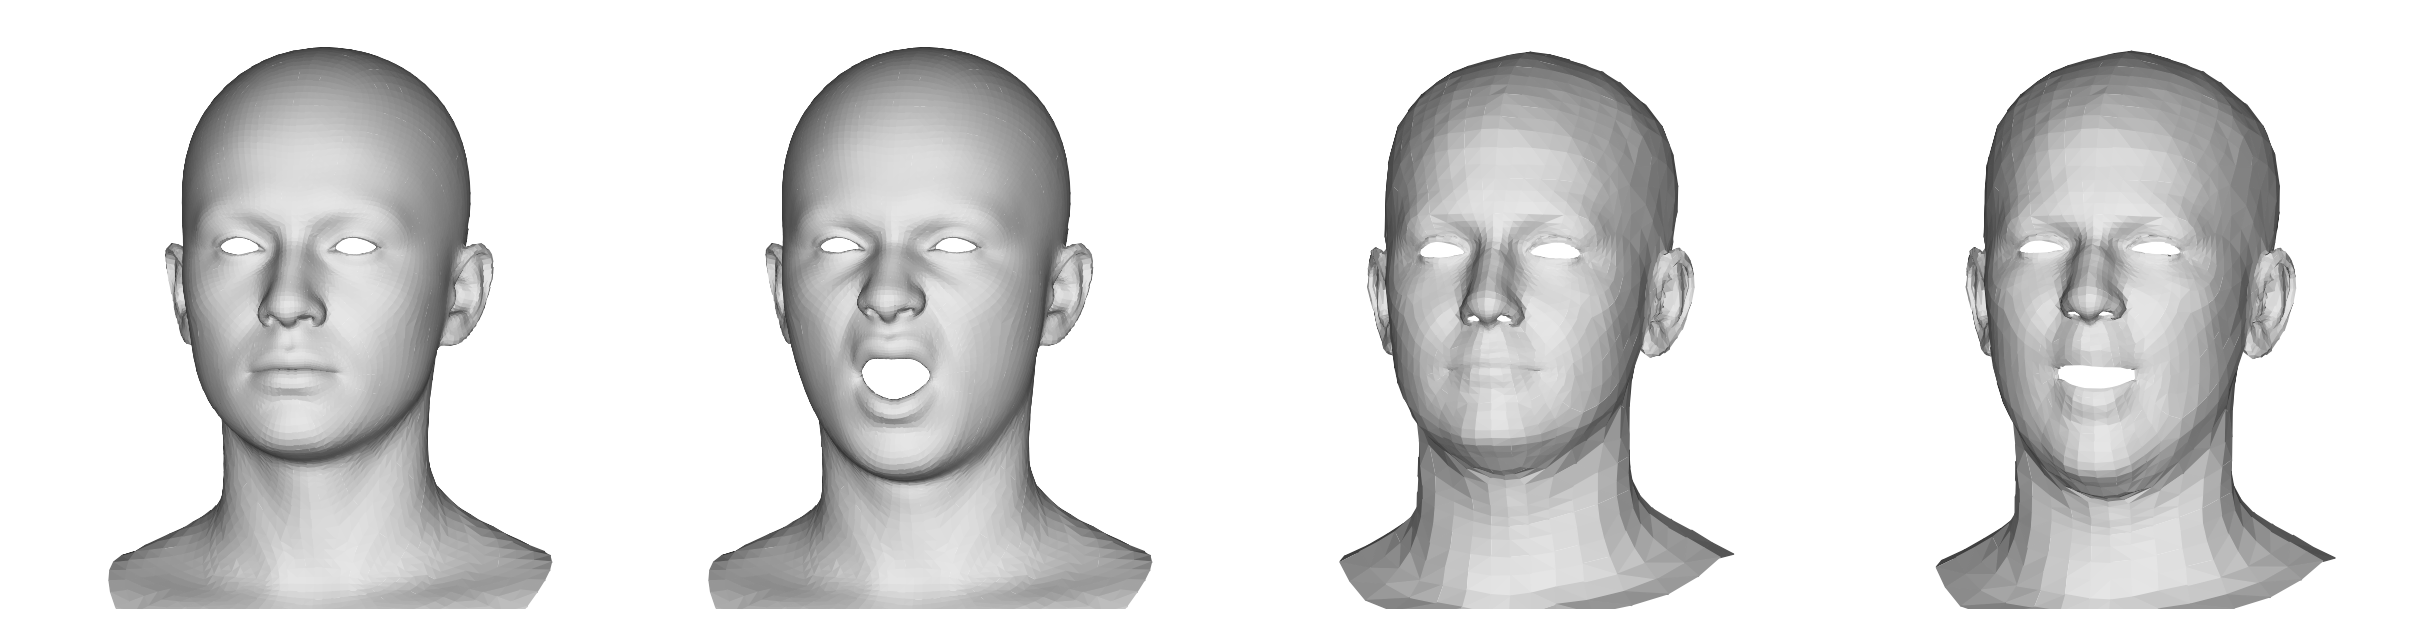

 source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


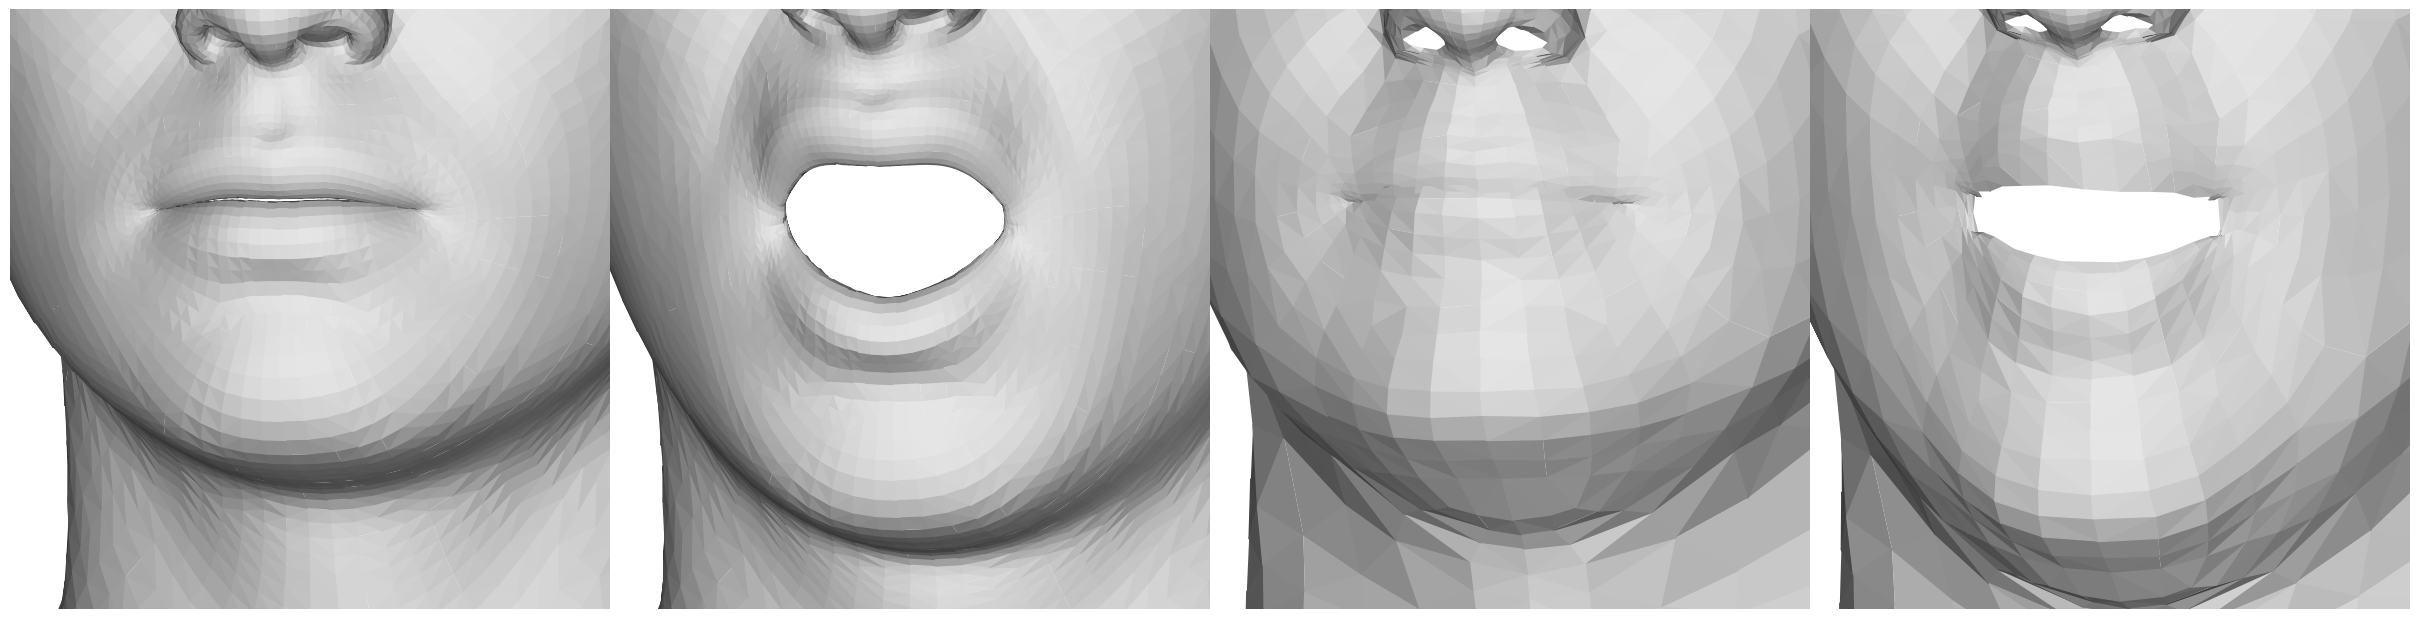

In [90]:
SIZE=6
M_SCALE=.6
SAVE=0
M_trns=np.array([0,0.,0])
rot_list=[[0,-10,0]]


v_list=[ src_mesh.vertices, vertices, pred_source.detach().cpu().numpy()[0], pred_outputs.detach().cpu().numpy()[0]]
v_list = [v * M_SCALE + M_trns for v in v_list]
f_list=[ src_mesh.faces, src_mesh.faces, tgt_mesh.faces, tgt_mesh.faces ]

print(' source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
# plot_mesh_gouraud(
#     v_list, f_list, mesh_scale=M_SCALE,
#     rot_list=rot_list*len(v_list), size=SIZE, mode='shade', 
#     bg_black=False, logdir=f"../_tmp", name=f"NBC-retarget-zoom", save=SAVE
# )
plot_image_array(
    v_list, f_list,
    rot_list=rot_list*len(v_list), size=SIZE, mode='shade', 
    bg_black=False, logdir=f"../_tmp", name=f"NBC-retarget", save=SAVE
)

M_SCALE=1.9
M_trns=np.array([0.1, 1, 0])

v_list=[ src_mesh.vertices, vertices, pred_source.detach().cpu().numpy()[0], pred_outputs.detach().cpu().numpy()[0]]
v_list = [v * M_SCALE + M_trns for v in v_list]
f_list=[ src_mesh.faces, src_mesh.faces, tgt_mesh.faces, tgt_mesh.faces ]

print(' source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')

plot_image_array(
    v_list, f_list,
    rot_list=rot_list*len(v_list), size=SIZE, mode='shade', 
    bg_black=False, logdir=f"../_tmp", name=f"NBC-retarget-zoom", save=SAVE
)

# Retarget animation

In [5]:
from dataloader_CBD import (
    EvalDataset,
    CBDDataBatch_eval,
    CBD_collate_wrapper_eval,
)
from functools import partial
from tqdm import tqdm
from glob import glob
import igl

import ipywidgets as widgets
import matplotlib.pyplot as plt

try:
    from matplotrender import *
except:
    !pip install git+https://github.com/chacorp/matplotrender.git
    from matplotrender import *

In [6]:
def get_mesh(selection, dataset, SELECT_MESH):
    if selection=='ict'or selection=='ict-cap':
        # id_vecs = np.load(f'{__abs_path__}/data/ICT_live_100/iden_vecs.npy')
        # id_vecs = np.load(f'{__abs_path__}/ict_face_pt/random_identity_vecs.npy')[:101]
        id_vecs = torch.load(f'{__abs_path__}/ict_face_pt/ict_id_vecs_test.pt').numpy()
        id_disps = dataset.ict_face_model.get_id_disp(id_vecs[SELECT_MESH])
        mesh_v = dataset.ict_face_model.neutral_verts.squeeze() + id_disps.squeeze()
        
        return mesh_v, dataset.ict_face_model.faces
    else:
        if selection=='voca':
            mesh = dataset.voca_mesh
        elif selection=='biwi':
            # mesh = dataset.biwi_mesh            
            biwi_trimesh = trimesh.load(f'{__abs_path__}/test-mesh/BIWI.ply')
            with open(f'{__abs_path__}/test-mesh/biwi_templates.pkl', 'rb') as f:
                mesh = pickle.load(f)
                
            mesh['face']=biwi_trimesh.faces
        elif selection=='mf_SEN':
            mesh = dataset.mf_SEN_mesh
        elif selection=='coma':
            mesh = dataset.coma_mesh
        elif selection=='mf_ROM':
            mesh = dataset.mf_ROM_mesh

        mesh_list = [idname for idname in mesh.keys() if idname!='face']
        mesh_v = mesh[mesh_list[SELECT_MESH]]

        if selection=='biwi':
            m_align = np.load(f'{__abs_path__}/utils/biwi/align.npy')
            mesh_v = np.concatenate((mesh_v,np.ones((mesh_v.shape[0],1))), axis=1) @ m_align.T
        return mesh_v, mesh['face']

In [7]:
device='cuda:0'
SRC_SELECT_DATA=4
SRC_SELECT_MESH=12
EXP_NUM=0

BS=1
data_name_list = ['voca','biwi','mf_SEN','coma','mf_ROM','ict','ict-cap'] # 0 1 2 3 4 5 6
src_selection = data_name_list[SRC_SELECT_DATA]

src_dataset = EvalDataset(
    data_name=src_selection, 
    toggle=False, 
    ict_cap_id_num  = SRC_SELECT_MESH,
    ict_cap_exp_num = EXP_NUM,
) # if eve-s01

src_dataloader = torch.utils.data.DataLoader(
    src_dataset,
    batch_size=BS,
    collate_fn=partial(CBD_collate_wrapper_eval, device=device),
)
len_data = len(src_dataset)
len_dataloader = len(src_dataloader)
print(f'max data length: {len_data}')
print(f'max dataloader: {len_dataloader}')

src_v, src_f = get_mesh(src_selection, src_dataset, SRC_SELECT_MESH)
src_n = igl.per_vertex_normals(src_v, src_f)

mf ROM data list exists: /source/sihun/NeuralFacialAnimation/utils/data/mf_ROM_vertex_data_test.txt
max data length: 11649
max dataloader: 11649


In [19]:
TGT_SELECT_DATA=6
TGT_SELECT_mesh=0

# ict test id [2 4 5 6 10 11 12] (at NFS)
# ict test id [0 5 6]
data_name_list = ['voca','biwi','mf_SEN','coma','mf_ROM','ict','ict-cap']
tgt_selection = data_name_list[TGT_SELECT_DATA]

tgt_dataset = EvalDataset(data_name=tgt_selection, toggle=False, ict_cap_id_num=TGT_SELECT_mesh) # if eve-s01

tgt_v, tgt_f = get_mesh(tgt_selection, tgt_dataset, TGT_SELECT_mesh)

tgt_n = igl.per_vertex_normals(tgt_v, tgt_f)
tgt_v_th = torch.tensor(tgt_v).float()[None].to(device)
tgt_n_th = torch.tensor(tgt_n).float()[None].to(device)

(5223, 3) (10278, 3) (11248, 3) (22288, 3)


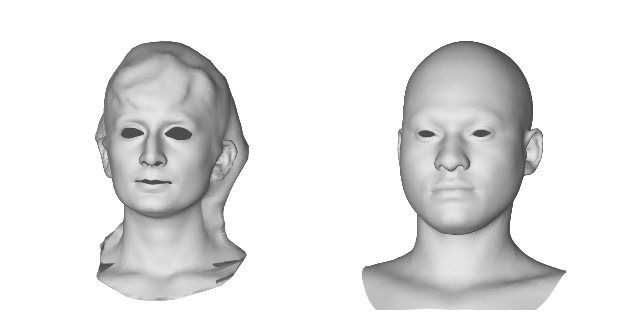

In [20]:
M_SCALE = 0.5
print(src_v.shape, src_f.shape, tgt_v.shape, tgt_f.shape)
v_list=[ src_v, tgt_v ]
f_list=[ src_f, tgt_f ]
SIZE=3
rot_list=[[0,-10,0]]

plot_mesh_gouraud(v_list, f_list, mesh_scale=M_SCALE,
        rot_list=rot_list*len(v_list), size=SIZE, mode='shade', bg_black=False)

In [21]:
# file_name = 'coma-to-mf_ROM'
# file_name = 'mf_ROM_test-to-mf_ROM_val'
# file_name = 'mf_ROM_test-to-mf_ROM_test'
# file_name = 'mf_SEN_test-to-mf_SEN_test'
if src_selection == 'ict-cap':
    file_name = f'{src_selection}-ID_{SRC_SELECT_MESH:03d}_test-to-{tgt_selection}-ID_{TGT_SELECT_mesh:03d}_test_{EXP_NUM:02d}'
else:
    if 'ict' in  tgt_selection:
        file_name = f'{src_selection}_test-to-{tgt_selection}_test-ID_{TGT_SELECT_mesh:03d}'
    else:
        file_name = f'{src_selection}_test-to-{tgt_selection}_test'
        # file_name = f'{src_selection}_test-to-{tgt_selection}_test'
        # file_name = f'{src_selection}_test-to-{tgt_selection}_val'
        # file_name = f'{src_selection}_test-to-{tgt_selection}_train'
a2b_retarget_path = __abs_path__ + '/eval_CBD/NeuralCage/'+file_name
print(a2b_retarget_path)
os.makedirs(a2b_retarget_path, exist_ok=True) 

/source/sihun/NeuralFacialAnimation/eval_CBD/NeuralCage/mf_ROM_test-to-ict-cap_test-ID_000


  0%|                                                                     | 0/11649 [00:00<?, ?it/s]


     source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


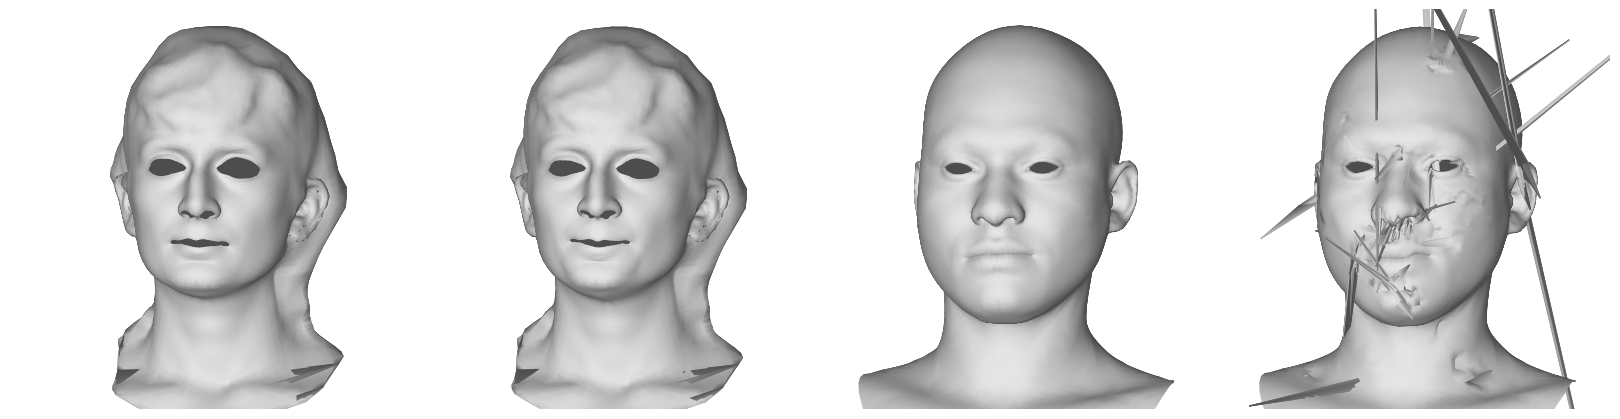

In [27]:
FRAME=0
pbar = tqdm(enumerate(src_dataloader), total=len_dataloader, ncols=100)
for index, batch in pbar:
    if FRAME == index:
        with torch.no_grad():
            pred_outputs, pred_source, key_d, key_s, key_weight = trainer.model.retarget(
                batch.template, batch.vertices, tgt_v_th, out_kw=True
            )

        pred_outputs_np = pred_outputs.detach().cpu().numpy()
        for b_idx in range(BS):
            np.save(a2b_retarget_path+f'/{index*BS+b_idx:05d}', pred_outputs_np[b_idx])
        break
    else:
        continue

SIZE=6
M_SCALE=.58
SAVE=0
M_SCALE_Zoom=2

M_trns=np.array([0,0.,0])
v_list=[
    batch.template.detach().cpu().numpy()[0],
    batch.vertices.detach().cpu().numpy()[0],
    tgt_v,
    pred_outputs.detach().cpu().numpy()[0],
]
# v_list = [v * M_SCALE + M_trns for v in v_list]
f_list=[ src_f, src_f, tgt_f, tgt_f]

print('     source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
plot_mesh_gouraud(v_list, f_list, mesh_scale=M_SCALE, mesh_trans=M_trns,
        rot_list=rot_list*len(v_list), size=4, mode='shade', bg_black=False)
# plot_mesh_gouraud(v_list, f_list, mesh_scale=M_SCALE_Zoom, mesh_trans=M_trns,
#         rot_list=rot_list*len(v_list), size=4, mode='shade', bg_black=False)

In [23]:
SRC_SELECT_MESH==TGT_SELECT_mesh

False

In [24]:
print(a2b_retarget_path)

/source/sihun/NeuralFacialAnimation/eval_CBD/NeuralCage/mf_ROM_test-to-ict-cap_test-ID_000


In [ ]:
print(a2b_retarget_path)

SELF_RETARGET = SRC_SELECT_MESH==TGT_SELECT_mesh
if SELF_RETARGET:
    print('self-retargeting!')
    pbar = tqdm(enumerate(src_dataloader), total=len_dataloader, ncols=100)
    for index, batch in pbar:
        with torch.no_grad():
            pred_outputs, pred_source, key_d, key_s, key_weight = trainer.model.retarget(
                batch.template, batch.vertices, tgt_v_th, out_kw=True
            )
    
        pred_outputs_np = pred_outputs.detach().cpu().numpy()
        for b_idx in range(BS):
            if b_idx < pred_outputs_np.shape[0]:
                np.save(a2b_retarget_path+f'/{index*BS+b_idx:05d}', pred_outputs_np[b_idx])
else:
    print('cross-retargeting!')
    pbar = tqdm(enumerate(src_dataloader), total=len_dataloader, ncols=100)
    for index, batch in pbar:
        with torch.no_grad():
            pred_outputs, pred_source, key_d, key_s, key_weight = trainer.model.retarget(
                batch.template, batch.vertices, tgt_v_th, out_kw=True
            )
    
        pred_outputs_np = pred_outputs.detach().cpu().numpy()
        for b_idx in range(BS):
            if b_idx < pred_outputs_np.shape[0]:
                np.save(a2b_retarget_path+f'/{index*BS+b_idx:05d}', pred_outputs_np[b_idx])

# NFR
### ICT self-retargeting    204/204 [33:25<17:56,  9.70s/it] 3260/3260 [39:46<00:00,  1.37it/s]
### MF_rom self-retargeting 729/729 [05:24<00:00,  2.25it/s]
                
# NFS
### ICT self-retargeting    204/204 [19:43<00:00,  5.80s/it] 3260/3260 [30:37<00:00,  1.77it/s] 
### MF_rom self-retargeting 729/729 [02:56<00:00,  4.13it/s]

# NBC (Ours)
### ICT self-retargeting    204/204 [11:28<00:00,  3.38s/it] 3260/3260 [23:46<00:00,  2.29it/s]
### MF_rom self-retargeting 729/729 [01:40<00:00,  7.29it/s] (frame: 11,664)

/source/sihun/NeuralFacialAnimation/eval_CBD/NeuralCage/mf_ROM_test-to-ict-cap_test-ID_000
cross-retargeting!


 18%|██████████▍                                               | 2090/11649 [02:16<10:50, 14.71it/s]

In [64]:
print(a2b_retarget_path)

SELF_RETARGET = SRC_SELECT_MESH==TGT_SELECT_mesh
if SELF_RETARGET:
    print('self-retargeting!')
    pbar = tqdm(enumerate(src_dataloader), total=len_dataloader, ncols=100)
    for index, batch in pbar:
        # predict_coordinate(tgt_neu_vert, tgt_neu_norm)
        # retarget_animation(src_neu_vert, src_neu_norm, src_def_vert, src_def_norm, key_weight)
        if index==0:
            src_template = batch.template
            src_template_normal = batch.template_normal
            with torch.no_grad():
                key_weight = trainer.model.predict_coordinate(src_template, src_template_normal)
        else:
            if (batch.template[0] - src_template[0]).mean() != 0:
                src_template = batch.template
                src_template_normal = batch.template_normal
                with torch.no_grad():
                    key_weight = trainer.model.predict_coordinate(src_template, src_template_normal)
                
        with torch.no_grad():
            pred_outputs, key_d = trainer.model.retarget_animation(
                batch.template, batch.template_normal, batch.vertices, batch.vertices_normal, key_weight
            )
            
        pred_outputs_np = pred_outputs.detach().cpu().numpy()
        for b_idx in range(BS):
            if b_idx < pred_outputs_np.shape[0]:
                np.save(a2b_retarget_path+f'/{index*BS+b_idx:05d}', pred_outputs_np[b_idx])
else:
    print('cross-retargeting!')
    key_weight = trainer.model.predict_coordinate(tgt_v_th, tgt_n_th)
    
    pbar = tqdm(enumerate(src_dataloader), total=len_dataloader, ncols=100)
    for index, batch in pbar:
        with torch.no_grad():            
            pred_outputs, key_d = trainer.model.retarget_animation(
                batch.template, batch.template_normal, batch.vertices, batch.vertices_normal, key_weight
            )
    
        pred_outputs_np = pred_outputs.detach().cpu().numpy()
        for b_idx in range(BS):
            if b_idx < pred_outputs_np.shape[0]:
                np.save(a2b_retarget_path+f'/{index*BS+b_idx:05d}', pred_outputs_np[b_idx])

/source/sihun/NeuralFacialAnimation/eval_CBD/2025-10-09-02-04-49-NGBCv5/mf_ROM_test-to-ict_test-ID_000
cross-retargeting!


100%|█████████████████████████████████████████████████████████| 11649/11649 [04:28<00:00, 43.33it/s]


## vis weight

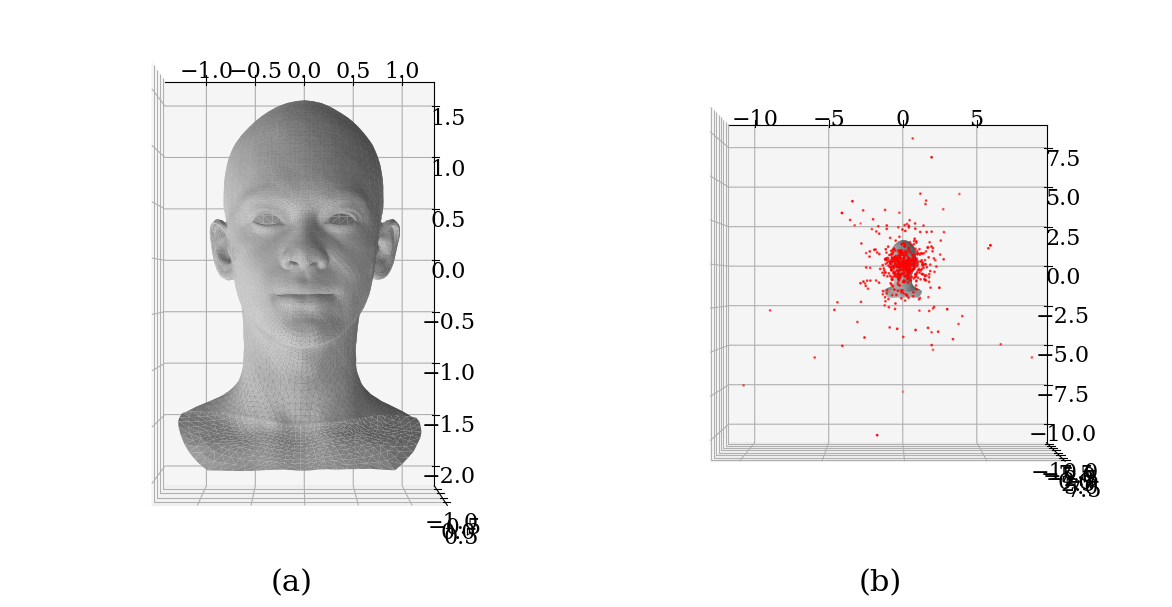

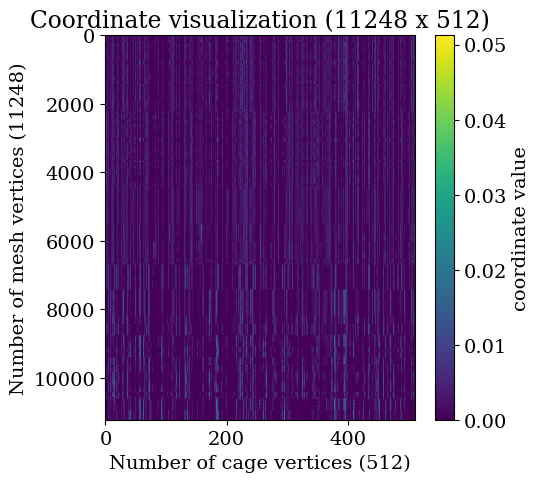

In [79]:
def draw_mesh_and_key_v(template_v_th, key_v, faces):
    
    rc = {
        "font.family" : "serif", 
        "font.size" : 16,
        "mathtext.fontset" : "stix",
    }
    FT = 22
    plt.rcParams.update(rc)
    plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]

    mesh_v = template_v_th.detach().cpu().numpy()
    points = key_v.detach().cpu().numpy()

    alpha=1.0
    
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(121, projection='3d')
    # ax.plot_surface(mesh_v[:, 0], mesh_v[:, 1], mesh_v[:, 2])
    ax.plot_trisurf(mesh_v[:, 0], mesh_v[:, 1], mesh_v[:, 2],
                    # triangles=faces, alpha=alpha, linewidth=0.0)
                    triangles=faces, alpha=alpha, color='lightgray', linewidth=0.0)
                    # triangles=faces, alpha=alpha, color='lightblue', linewidth=0.0)
                    # triangles=faces, alpha=alpha, color='gray', linewidth=0.0)
    ax.view_init(elev=90, azim=-90)
    # ax.set_aspect('equal')
    ax.set_box_aspect([1,1.5,1])
    ax.set_title("(a)", fontsize=FT, y=-0.05)
    
    ax = fig.add_subplot(122, projection='3d')    
    ax.plot_trisurf(mesh_v[:, 0], mesh_v[:, 1], mesh_v[:, 2],
                    # triangles=faces, alpha=alpha, linewidth=0.0)
                    triangles=faces, alpha=alpha, color='lightgray', linewidth=0.0)
                    # triangles=faces, alpha=alpha, color='lightblue', linewidth=0.0)
                    # triangles=faces, alpha=alpha, color='gray', linewidth=0.0)

    ax.scatter(points[:, 0], points[:, 1], points[:, 2], color='r', s=1)    
    ax.view_init(elev=90, azim=-90)
    # ax.set_aspect('equal')
    ax.set_box_aspect([1.5, 1.5, 1.5])
    ax.set_title("(b)", fontsize=FT, y=-0.05)
    plt.tight_layout()
    plt.show()

def draw_key_weight(data):
    rc = {
        "font.family" : "serif", 
        "font.size" : 14,
        "mathtext.fontset" : "stix",
    }
    FT = 20
    plt.rcParams.update(rc)
    plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
    
    data = data.detach().cpu().numpy()
    num_sample, num_cage = data.shape[0], data.shape[1]
    #normed = (data - data.min(1,keepdims=True)) / (data.max(1,keepdims=True) - data.min(1,keepdims=True))
    #print(normed.min(),normed.max())
    
    plt.figure(figsize=(5, 5))  # set figure size to 5x5 inches
    plt.imshow(data, aspect='auto', cmap='viridis', vmin=data.min(), vmax=data.max())  # aspect='auto' to stretch
    plt.colorbar(label='coordinate value')  # optional colorbar
    
    plt.xlabel(f"Number of cage vertices ({num_cage})")
    plt.ylabel(f"Number of mesh vertices ({num_sample})")
    plt.title(f"Coordinate visualization ({num_sample} x {num_cage})")
    plt.show()
    
NNN=0 
# print(key_weight[0].sum(0).shape, key_weight[0].sum(0))
# print(key_weight[0,0])
# print(torch.allclose(key_weight[0], key_weight[1]))
# print(torch.nn.functional.mse_loss(key_weight[0], key_weight[1]).item())

# print(key_weight[0].sum(1).shape, key_weight[0].sum(1))
draw_mesh_and_key_v(pred_source[NNN], key_d[NNN], tgt_f)
draw_key_weight(key_weight[0])

## save GT

In [45]:
# file_name = 'GT-mf_ROM_test-to-mf_ROM_test'
# GT_file_name = 'GT-'+file_name
GT_file_name = f'GT-{src_selection}_test-to-{src_selection}_test_{EXP_NUM:02d}'

GT_a2b_retarget_path = __abs_path__ + '/eval_CBD/'+ GT_file_name
print(GT_a2b_retarget_path)
os.makedirs(GT_a2b_retarget_path, exist_ok=True) 

/source/sihun/NeuralFacialAnimation/eval_CBD/GT-ict-cap_test-to-ict-cap_test_00


In [213]:
pbar = tqdm(enumerate(src_dataloader), total=len_dataloader, ncols=100)
for index, batch in pbar:
    gt_outputs_np = batch.vertices.detach().cpu().numpy()
    for b_idx in range(BS):
        if b_idx < gt_outputs_np.shape[0]:
            np.save(GT_a2b_retarget_path+f'/{index*BS+b_idx:05d}', gt_outputs_np[b_idx])

100%|███████████████████████████████████████████████████████████| 1147/1147 [08:11<00:00,  2.33it/s]


## load

In [46]:
print(a2b_retarget_path)
mesh_file_paths = sorted(glob(a2b_retarget_path+'/*.npy'))
len_mesh_file_paths=len(mesh_file_paths)
print(len(mesh_file_paths))

print(GT_a2b_retarget_path)
GT_mesh_file_paths = sorted(glob(GT_a2b_retarget_path+'/*.npy'))
GT_len_mesh_file_paths=len(GT_mesh_file_paths)
print(len(GT_mesh_file_paths))

/source/sihun/NeuralFacialAnimation/eval_CBD/2025-10-09-02-04-49-NGBCv5/ict-cap-ID_002_test-to-mf_ROM-ID_012_test_00
183
/source/sihun/NeuralFacialAnimation/eval_CBD/GT-ict-cap_test-to-ict-cap_test_00
183


In [22]:
__mse__ = 0
for gt, pred in zip(GT_mesh_file_paths, mesh_file_paths):
    pred = np.load(pred)
    gt = np.load(gt)
    __mse__ += np.power(gt - pred, 2).mean()
__mse__ = __mse__ / len(GT_mesh_file_paths)
print(f"MSE: {__mse__:.5e}")

MSE: 3.70772e-04


In [60]:
src_f.shape

(22288, 3)

In [47]:
SAVE=0
rot_list=[[0,-10,0]]
M_SCALE=0.6
def update_frame(frame):
    plt.close()
    
    vvv= np.load(mesh_file_paths[frame]).squeeze()
    vvvGT= np.load(GT_mesh_file_paths[frame]).squeeze()
    
    v_list = [vvvGT, vvv]
    f_list = [src_f, tgt_f]
    # plot_mesh_gouraud(
    #     v_list, f_list, mesh_scale=M_SCALE,
    #     rot_list=rot_list*len(v_list), size=4, mode='shade', bg_black=False)
    v_list = [v * M_SCALE for v in v_list]
    plot_image_array(
            v_list, f_list,
            rot_list=rot_list*len(v_list), size=4, mode='shade', bg_black=False
        )

slider = widgets.IntSlider(value=0, min=0, max=len_mesh_file_paths-1, step=1, description='Frame:')

widgets.interactive(update_frame, frame=slider)
# widgets.interact(update_frame, frame=slider)

interactive(children=(IntSlider(value=0, description='Frame:', max=182), Output()), _dom_classes=('widget-inte…

In [ ]:
__mse__ = 0
for gt, pred in zip(GT_mesh_file_paths, nfr_mesh_file_paths):
    pred = np.load(pred)
    gt = np.load(gt)
    __mse__ += np.power(gt - pred, 2).mean()
__mse__ = __mse__ / len(GT_mesh_file_paths)
print(f"MSE: {__mse__:.5e}")

# Load widget

In [21]:
import ipywidgets as widgets
# from ipywidgets import interact, FloatSlider

(11248, 3) (11248, 3)


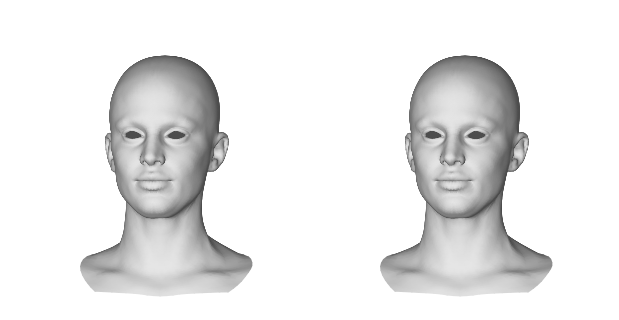

In [52]:
data_name_list = ['voca','biwi','mf_SEN','coma','mf_ROM','ict','ict-cap'] # 0 1 2 3 4 5

SRC_SELECT_DATA=6
SRC_SELECT_MESH=2
EXP_NUM=0

TGT_SELECT_DATA=6
TGT_SELECT_mesh=2

src_selection = data_name_list[SRC_SELECT_DATA]
tgt_selection = data_name_list[TGT_SELECT_DATA]

device='cuda:0'

src_dataset = EvalDataset(data_name=src_selection, toggle=False) # if eve-s01
src_v, src_f = get_mesh(src_selection, src_dataset, SRC_SELECT_MESH)
src_n = igl.per_vertex_normals(src_v, src_f)

tgt_dataset = EvalDataset(data_name=tgt_selection, toggle=False) # if eve-s01
tgt_v, tgt_f = get_mesh(tgt_selection, tgt_dataset, TGT_SELECT_mesh)
tgt_n = igl.per_vertex_normals(tgt_v, tgt_f)

M_SCALE = 0.5
print(src_v.shape, tgt_v.shape)
v_list=[ src_v, tgt_v ]
f_list=[ src_f, tgt_f ]
SIZE=3
rot_list=[[0,-10,0]]

plot_mesh_gouraud(v_list, f_list, mesh_scale=M_SCALE,
        rot_list=rot_list*len(v_list), size=SIZE, mode='shade', bg_black=False)

# v_list=[v * M_SCALE for v in v_list]
# rot_list=[[0,-10,0]]
# plot_image_array(
#     v_list, f_list,
#     rot_list=rot_list*len(v_list), 
#     size=SIZE, bg_black=False, mode='shade', save=True,
#     logdir=f"fig/", name=f"{file_name}-id_{TGT_SELECT_mesh:02d}-neutral", 
# )

In [54]:
#######################################################
ckpt_path = '2025-10-09-02-04-49-NGBCv5'
# ckpt_path = '2025-10-09-02-04-49-NGBCv5_'
# ckpt_path = '2025-09-29-14-48-17-NGBCv8'
# ckpt_path = '2025-09-27-12-04-29-NGBCv5'
# ckpt_path = '2025-09-27-08-05-11-NGBCv5'
if src_selection == 'ict-cap':
    file_name = f'{src_selection}-ID_{SRC_SELECT_MESH:03d}_test-to-{tgt_selection}-ID_{TGT_SELECT_mesh:03d}_test_{EXP_NUM:02d}'
else:
    file_name = f'{src_selection}_test-to-{tgt_selection}_test'
# file_name = f'{src_selection}_test-to-{tgt_selection}_val'
# file_name = f'{src_selection}_test-to-{tgt_selection}_train'
#######################################################

a2b_retarget_path = __abs_path__ + '/eval_CBD/'+ckpt_path+'/'+file_name
print(a2b_retarget_path)
mesh_file_paths = sorted(glob(a2b_retarget_path+'/*.npy'))
len_mesh_file_paths=len(mesh_file_paths)
print(len_mesh_file_paths)

a2b_retarget_path = __abs_path__ + '/eval_CBD/nfr/'+file_name
print(a2b_retarget_path)
nfr_mesh_file_paths = sorted(glob(a2b_retarget_path+'/*.npy'))
len_nfr_mesh_file_paths=len(nfr_mesh_file_paths)
print(len_nfr_mesh_file_paths)

a2b_retarget_path = __abs_path__ + '/eval_CBD/nfs/'+file_name
print(a2b_retarget_path)
nfs_mesh_file_paths = sorted(glob(a2b_retarget_path+'/*.npy'))
len_nfs_mesh_file_paths=len(nfs_mesh_file_paths)
print(len_nfs_mesh_file_paths)

if src_selection == 'ict-cap':
    GT_a2b_retarget_path = __abs_path__ + '/eval_CBD/GT-'+f'{src_selection}_test-to-{src_selection}_test_{EXP_NUM:02d}'
else:
    GT_a2b_retarget_path = __abs_path__ + '/eval_CBD/GT-'+f'{src_selection}_test-to-{src_selection}_test'
    
print(GT_a2b_retarget_path)
GT_mesh_file_paths = sorted(glob(GT_a2b_retarget_path+'/*.npy'))
GT_len_mesh_file_paths=len(GT_mesh_file_paths)
print(GT_len_mesh_file_paths)

/source/sihun/NeuralFacialAnimation/eval_CBD/2025-10-09-02-04-49-NGBCv5/ict-cap-ID_002_test-to-ict-cap-ID_002_test_00
183
/source/sihun/NeuralFacialAnimation/eval_CBD/nfr/ict-cap-ID_002_test-to-ict-cap-ID_002_test_00
183
/source/sihun/NeuralFacialAnimation/eval_CBD/nfs/ict-cap-ID_002_test-to-ict-cap-ID_002_test_00
183
/source/sihun/NeuralFacialAnimation/eval_CBD/GT-ict-cap_test-to-ict-cap_test_00
183


In [55]:
SAVE=0
SIZE=5
button=False
# rot_list=[[0,0,0]]
M_SCALE=0.6
M_SCALE_zoom=1.5
# M_TRANS_zoom=np.array([0,0.5,0])
M_TRANS_zoom=np.array([0,0.52,0])

def update_frame(frame, y_rot, save):
    global button
    plt.close()
    rot_list=[[0,y_rot,0]]
    _ours_= np.load(mesh_file_paths[frame]).squeeze()
    _nfr_= np.load(nfr_mesh_file_paths[frame]).squeeze()
    _nfs_= np.load(nfs_mesh_file_paths[frame]).squeeze()
    _GT_= np.load(GT_mesh_file_paths[frame]).squeeze()
    
    # v_list = [src_v, _GT_, _ours_, _nfr_]
    # v_list = [src_v, _GT_, tgt_v, _ours_, _nfs_, _nfr_]
    v_list =[_GT_]
    # v_list = [_GT_, _ours_, _nfs_, _nfr_] # mf_test-to-mf_test
    v_list += [_ours_, _nfs_, _nfr_] # mf_test-to-mf_test
    # v_list = [tgt_v, _ours_, _nfs_, _nfr_] # mf_test-to-mf_train
    
    f_list = [src_f]
    f_list += [tgt_f]*(len(v_list)-1)
    
    v_list1=[v * M_SCALE for v in v_list]
    plot_image_array(
        v_list1, f_list,
        rot_list=rot_list*len(v_list), 
        size=SIZE, bg_black=False, mode='shade', save=False
    )
    
    v_list2=[v * M_SCALE_zoom +M_TRANS_zoom for v in v_list]
    plot_image_array(
        v_list2, f_list,
        rot_list=rot_list*len(v_list), 
        size=SIZE, bg_black=False, mode='shade', save=False
    )
    if save!=button:
        plot_image_array(
            v_list1, f_list,
            rot_list=rot_list*len(v_list), 
            size=SIZE, bg_black=False, mode='shade', 
            logdir=f"fig/", 
            name=f"{file_name}-{frame:05d}", 
            save=True
        )
        plot_image_array(
            v_list2, f_list,
            rot_list=rot_list*len(v_list), 
            size=SIZE, bg_black=False, mode='shade', 
            logdir=f"fig/", 
            name=f"{file_name}-{frame:05d}-zoom", 
            save=True
        )
        button=save
        print('cl')
    #     save=False

    # def on_click(change):
    #     print('clicked')
     
    # save.observe(on_click, 'value')

    # plot_mesh_gouraud(
    #     v_list, f_list, mesh_scale=M_SCALE, 
    #     # is_diff=True, 
    #     # diff_base=src_v, # calculates difference based on this mesh
    #     diff_base=_GT_, # calculates difference based on this mesh
    #     rot_list=rot_list*len(v_list), size=SIZE, mode='shade', bg_black=False)

sliders = {
    'frame': widgets.IntSlider(value=0, min=0, max=len_mesh_file_paths-1, step=1),
    'y_rot': widgets.FloatSlider(value=0, min=-180, max=180, step=.1),
    'save': widgets.ToggleButton(
        value=False,
        description='save',
        disabled=False,
        button_style='', # 'success', 'info', 'warning', 'danger' or ''
        tooltip='Description',
        icon='check' # (FontAwesome names without the `fa-` prefix)
    )
}
# widgets.interactive(update_frame, frame=slider)
widgets.interact(update_frame, **sliders)

interactive(children=(IntSlider(value=0, description='frame', max=182), FloatSlider(value=0.0, description='y_…

<function __main__.update_frame(frame, y_rot, save)>

# test

In [ ]:
import numpy as np
from utils.exp_utils import PCA_holder
import pickle
import os
from glob import glob

import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib import rc
from sklearn.decomposition import PCA
from ipywidgets import interact, FloatSlider
import matplotlib.tri as mtri

In [ ]:

# ---------- Plot Function ----------
SIZE= 5
def plot_pca_shape(**kwargs):
    # PC0 ~ PC19
    #keys = sorted(kwargs.keys(), key=lambda k: int(k[2:]))
    keys = sorted(list(kwargs.keys()))[:-1]
    visible_coeffs = np.array([kwargs[k] for k in keys])

    # 전체 100차원 중 visible 부분만 채우고 나머지는 0으로
    full_coeffs = np.zeros((1, n_components))
    full_coeffs[0, :n_slider] = visible_coeffs 
    full_coeffs = full_coeffs * np.sqrt(pca_holder.explained_variance_)
    
    model = yrotate(-kwargs["y_rot"])
    view  = translate(0, 0, -3.5)
    proj  = perspective(55, 1, 1, 100)
    MVP   = proj @ view @ model

    V_flat = pca_holder.inverse_transform(full_coeffs)
    print(V_flat.shape, V_flat.min(0), V_flat.max(0))
    
    V = V_flat.reshape(-1, 3)
    V = normalize_homogeneous(V)
    V = V @ MVP.T
    V /= V[:, 3].reshape(-1, 1)

    VF = V[faces]
    T = VF[:, :, :2]
    Z = -VF[:, :, 2].mean(axis=1)
    Z = (Z - Z.min()) / ((Z.max() - Z.min())+1e-12)
    C = plt.get_cmap("magma")(Z)
    I = np.argsort(Z)

    T, C = T[I, :], C[I, :]
    fig = plt.figure(figsize=(SIZE, SIZE))
    ax = fig.add_axes([0, 0, 1, 1], xlim=[-1, 1], ylim=[-1, 1], aspect=1, frameon=False)
    collection = PolyCollection(T, closed=True, linewidth=0.1, facecolor=C, edgecolor="black")
    ax.add_collection(collection)
    plt.show()

# ===== 슬라이더 구성 (PC0~PC19) =====
sliders = {
    f"PC{i}": FloatSlider(value=0.0, min=-3.0, max=3.0, step=0.1, layout={"width": "300px"})
    for i in range(n_slider)
}
sliders["y_rot"]=FloatSlider(value=0.0, min=-90, max=90, step=0.1, layout={"width": "300px"})

interact(plot_pca_shape, **sliders)

print(LST[NUM])
print('123')